## Alda lets GO

In [ ]:
%load_ext autoreload
%autoreload 2
%pip install pandas
%pip install matplotlib
%matplotlib inline
%pip install torch 'transformers[torch]' datasets
%pip install torch==2.6.0 --index-url https://download.pytorch.org/whl/cu124 #?
%pip install sentencepiece protobuf accelerate
%pip install scikit-learn
%pip install seaborn
%pip install -U google-genai openai

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='urllib3')

# The Algorithmic councils of THM SimpleText 2026

## First Council - BERT Classifiers

### The 5 models

1. DistilBERT: lighter bert model, fast and small.

2. RoBERTa: used by AIIRLab, for multi-label classification

3. SciBERT: scientifc bert model

4. BERT-base: industry standard

In [1]:
# cache clearing shit
import gc
import torch
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

# 1. Generating BERT data

Set `train_size` and `eval_size` according to your systems capabilities.

In [ ]:
import os
from berthold_classifying import BERTCouncil
from stripper import strip_confident_nones

distilbert = BERTCouncil(distilbert=True)
status = distilbert.run_all_models(
    train_path="Task_2_new/train_data.json",
    test_path="Task_2_new/dev_data.json",
    train_size=8,
    eval_size=16
)
print(status)
os.rename(
        "submission_distilbert_sentences.json",
        "submission_distilbert_sentences_DEV.json"
)
status = distilbert.run_all_models(
    train_path="Task_2_new/train_data.json",
    test_path="Task_2_new/test_data.json",
    train_size=8,
    eval_size=16
)
print(status)

strip_confident_nones(
    original_test_path="Task_2_new/test_data.json",
    distilbert_predictions_path="submission_distilbert_sentences.json",
    output_filtered_path="test_data_filtered.json",
    none_threshold=0.8
)



council = BERTCouncil(roberta=True, scibert=True, bert=True)
status = council.run_all_models(
    train_path="Task_2_new/train_data.json",
    test_path="Task_2_new/dev_data.json",
    train_size=8,
    eval_size=16
)
print(status)
models = ["bert", "roberta", "scibert"]
for model in models:
    os.rename(
        f"submission_{model}_sentences.json",
        f"submission_{model}_sentences_DEV.json"
    )
status = council.run_all_models(
    train_path="Task_2_new/train_data.json",
    test_path="Task_2_new/test_data_filtered.json",
    train_size=8,
    eval_size=16
)
print(status)

## 2. The first judge
Random Forest part 1. BERT hunger games

`len` acts as a filter to check for smaller sentences (which are more likely to be "none") or larger sentences, which imply errors

`ratio` is a small classification, if the ratio is 1.5, an overgeneration is likely, if the ratio is above 3.0 generation failure or repetitive content is likely

`tiny` counters false positives

/Users/ligma/PycharmProjects/THM-SimpleText-2026/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


                         precision    recall  f1-score   support

                   None       1.00      0.97      0.98     17068
     GENERATION_FAILURE       0.89      0.93      0.91       672
    LEAKED_INSTRUCTIONS       0.82      0.93      0.87       473
   UNGROUNDED_INJECTION       0.40      0.84      0.54       329
     REPETITIVE_CONTENT       0.60      0.73      0.66        93
GROUNDED_OVERGENERATION       0.00      0.00      0.00         3

               accuracy                           0.96     18638
              macro avg       0.62      0.73      0.66     18638
           weighted avg       0.98      0.96      0.97     18638



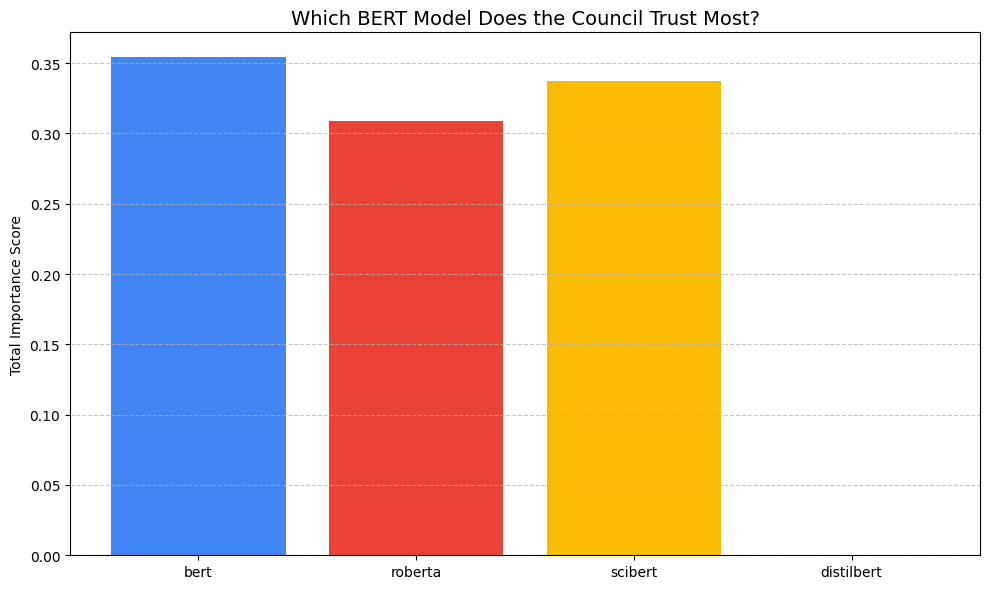

Saved 105001 sentence records → submission_meta_ensemble.json
Saved 6728 document records → submission_meta_ensemble_docs.json


In [2]:
from i_know_where_you_stand import (create_meta_ensemble_oof, run_inference_and_save)

model_files = [
    "submission_distilbert_sentences_DEV.json",
    "submission_bert_sentences_DEV.json",
    "submission_roberta_sentences_DEV.json",
    "submission_scibert_sentences_DEV.json",
]

meta_model, df_train_meta, feature_cols = create_meta_ensemble_oof(
    model_files=model_files,
    train_json_path="Task_2_new/dev_data.json",
    n_splits=5
)

feature_cols = [col.replace("_DEV", "") for col in feature_cols]

test_model_files = [
    "submission_distilbert_sentences.json",
    "submission_bert_sentences.json",
    "submission_roberta_sentences.json",
    "submission_scibert_sentences.json",
]

run_inference_and_save(
    meta_model=meta_model,
    test_model_files=test_model_files,
    test_json_path="Task_2_new/test_data.json",
    feature_cols=feature_cols,
    output_file="submission_meta_ensemble.json",
    team_name="TeamTEAM",
)

# 3. Stripping the meta ensemble output
this one yoinks all "none" entries and entries, where each bert model agrees on one error

In [3]:
import json
import pandas as pd

NONE_PROB_THRESHOLD = 0.8
DISTILBERT_NONE_THRESHOLD = 0.8
BERT_AGREEMENT_THRESHOLD = 0.8

NON_NONE_LABELS = [
    "GENERATION_FAILURE",
    "LEAKED_INSTRUCTIONS",
    "UNGROUNDED_INJECTION",
    "REPETITIVE_CONTENT",
    "GROUNDED_OVERGENERATION",
]

with open("submission_meta_ensemble.json", "r") as f:
    ensemble = json.load(f)

print(f"Original record count: {len(ensemble)}")

def is_confident_none(record):
    return record.get("None_prob", 0.0) >= NONE_PROB_THRESHOLD

after_pass1 = [
    r for r in ensemble
    if not is_confident_none(r)
]

removed_pass1 = len(ensemble) - len(after_pass1)

print(f"Pass 1 removed: {removed_pass1}")
print(f"Remaining after pass 1: {len(after_pass1)}")

def was_filtered_before_council(record):
    distilbert_none = (
        record.get("bert_distilbert", {})
        .get("None", 0.0)
    )

    other_models_missing = all(
        all(v == 0.0 for v in record.get(model_key, {}).values())
        for model_key in [
            "bert_bert",
            "bert_roberta",
            "bert_scibert",
        ]
    )

    return (
        other_models_missing
        and distilbert_none >= DISTILBERT_NONE_THRESHOLD
    )

after_pass2 = [
    r for r in after_pass1
    if not was_filtered_before_council(r)
]

removed_pass2 = len(after_pass1) - len(after_pass2)

print(f"Pass 2 removed: {removed_pass2}")
print(f"Remaining after pass 2: {len(after_pass2)}")

def all_models_agree_on_error(record):
    bert_keys = [
        k for k in record
        if k.startswith("bert_")
    ]

    valid_models = []

    for model_key in bert_keys:
        probs = record[model_key]

        if any(v > 0.0 for v in probs.values()):
            valid_models.append(model_key)

    if len(valid_models) < 2:
        return False

    for error_label in NON_NONE_LABELS:
        all_agree = all(
            record[model_key].get(error_label, 0.0)
            >= BERT_AGREEMENT_THRESHOLD
            for model_key in valid_models
        )

        if all_agree:
            return True

    return False

after_pass3 = [
    r for r in after_pass2
    if not all_models_agree_on_error(r)
]

removed_pass3 = len(after_pass2) - len(after_pass3)

print(f"Pass 3 removed: {removed_pass3}")
print(f"Remaining after pass 3: {len(after_pass3)}")


output_path = "submission_meta_ensemble_stripped.json"

with open(output_path, "w") as f:
    json.dump(after_pass3, f, indent=4)

print(f"\nSaved {len(after_pass3)} records → {output_path}")


if len(after_pass3) > 0:
    labels_remaining = [
        r["predicted_label"]
        for r in after_pass3
    ]

    label_counts = pd.Series(labels_remaining).value_counts()

    print("\nLabel distribution:")
    print(label_counts.to_string())

Original record count: 105001
Pass 1 removed: 31
Remaining after pass 1: 104970
Pass 2 removed: 97424
Remaining after pass 2: 7546
Pass 3 removed: 2928
Remaining after pass 3: 4618

Saved 4618 records → submission_meta_ensemble_stripped.json

Label distribution:
None                    2118
UNGROUNDED_INJECTION    1174
LEAKED_INSTRUCTIONS      622
REPETITIVE_CONTENT       357
GENERATION_FAILURE       347


# 4. The second council
chatgpt uses his insane authority as the only judge, jury and executioner to decide the fate of the the dataset

if there is enough money in the bank the llm_council can be used instead of the gpt_dictator. the council uses gemini as well to further increase the overall sum of results

In [11]:
import pandas as pd
import json
from gpt_dictator import run_council_batch

with open("submission_meta_ensemble_stripped.json", "r") as f:
    stripped_list = json.load(f)

prompts_list = {
    "Factuality_Check": (
        "Look at this source: '{src}'. "
        "Does the simplification '{simp}' hallucinate new facts? Answer YES or NO.",
        5,
    ),
    "Error_Detection": (
        "Analyze the simplification '{simp}' against the source '{src}'.\n"
        "Identify errors from this taxonomy (and only use these):\n"
        "- GENERATION_FAILURE\n"
        "- LEAKED_INSTRUCTIONS\n"
        "- UNGROUNDED_INJECTION\n"
        "- REPETITIVE_CONTENT\n"
        "- GROUNDED_OVERGENERATION\n"
        "If clean, state 'NO ERRORS'.",
        150,
    ),
}

sample_size = None # change to none, for final run (note that sample size is based on meta_ensemble_stripped)
entries_to_run = stripped_list[:sample_size] if sample_size else stripped_list

print(f"Sending {len(entries_to_run)} sentences to LLM council (batched)...")

all_council_results = await run_council_batch(
    prompts_list,
    entries_to_run,
    concurrency=5, # the parallel batches
)

print(f"Done. {len(all_council_results)} LLM responses collected.")
df_council = pd.DataFrame(all_council_results)
df_council.head()

Sending 4618 sentences to LLM council (batched)...
[LLMCouncil] Batch submitted — id: batch_6a18d4a3e0008190865ad668b6dba145  status: validating
[LLMCouncil] Polling batch batch_6a18d4a3e0008190865ad668b6dba145 — status: validating  done: 0/0  failed: 0
[LLMCouncil] Polling batch batch_6a18d4a3e0008190865ad668b6dba145 — status: validating  done: 0/0  failed: 0
[LLMCouncil] Polling batch batch_6a18d4a3e0008190865ad668b6dba145 — status: validating  done: 0/0  failed: 0
[LLMCouncil] Polling batch batch_6a18d4a3e0008190865ad668b6dba145 — status: in_progress  done: 0/9236  failed: 0
[LLMCouncil] Polling batch batch_6a18d4a3e0008190865ad668b6dba145 — status: in_progress  done: 0/9236  failed: 0
[LLMCouncil] Polling batch batch_6a18d4a3e0008190865ad668b6dba145 — status: in_progress  done: 0/9236  failed: 0
[LLMCouncil] Polling batch batch_6a18d4a3e0008190865ad668b6dba145 — status: in_progress  done: 0/9236  failed: 0
[LLMCouncil] Polling batch batch_6a18d4a3e0008190865ad668b6dba145 — status: 

,snt_id,task,model,response
0,test_00002_0,Factuality_Check,ChatGPT,NO
1,test_00002_0,Error_Detection,ChatGPT,GROUNDED_OVERGENERATION
2,test_00002_1,Factuality_Check,ChatGPT,NO
3,test_00002_1,Error_Detection,ChatGPT,UNGROUNDED_INJECTION
4,test_00002_5,Factuality_Check,ChatGPT,NO


# 5. Merging back together
takes llm outputs and puts them back to the former meta_ensemble (full)


In [12]:
from collections import defaultdict

with open("submission_meta_ensemble.json", "r") as f:
    full_ensemble = json.load(f)

llm_lookup = defaultdict(list)
for row in all_council_results:
    llm_lookup[row["snt_id"]].append(row)

PLACEHOLDER = "empty, due to none"

task_model_pairs = sorted({
    (r["task"], r["model"]) for r in all_council_results
})

def build_llm_columns(snt_id):
    responses = llm_lookup.get(snt_id, [])

    if not responses:
        cols = {
            f"llm_{model.lower()}_{task.lower()}": PLACEHOLDER
            for task, model in task_model_pairs
        }
        cols["llm_reviewed"] = False
    else:
        cols = {
            f"llm_{r['model'].lower()}_{r['task'].lower()}": r["response"]
            for r in responses
        }
        cols["llm_reviewed"] = True

    return cols

merged_ensemble = []
for record in full_ensemble:
    llm_cols = build_llm_columns(record["snt_id"])
    merged_ensemble.append({**record, **llm_cols})

output_json = "submission_meta_ensemble_with_llm.json"
with open(output_json, "w") as f:
    json.dump(merged_ensemble, f, indent=4)

df_merged = pd.DataFrame(merged_ensemble)

reviewed = int(df_merged["llm_reviewed"].sum())
skipped  = int((~df_merged["llm_reviewed"]).sum())

print(f"\nMerged ensemble saved.")
print(f"  Total sentences : {len(df_merged)}")
print(f"  LLM reviewed    : {reviewed}")
print(f"  Skipped (None)  : {skipped}")
print(f"  JSON → {output_json}")

df_merged.head()


Merged ensemble saved.
  Total sentences : 105001
  LLM reviewed    : 4618
  Skipped (None)  : 100383
  JSON → submission_meta_ensemble_with_llm.json


,snt_id,doc_id,source_sentence,simplified_sentence,run_id,predicted_label,None_prob,GENERATION_FAILURE_prob,LEAKED_INSTRUCTIONS_prob,UNGROUNDED_INJECTION_prob,REPETITIVE_CONTENT_prob,GROUNDED_OVERGENERATION_prob,bert_distilbert,bert_bert,bert_roberta,bert_scibert,llm_chatgpt_error_detection,llm_chatgpt_factuality_check,llm_reviewed
0,test_00001_0,test_00001,We found 18 studies that evaluated the effect ...,The results of 18 studies evaluating the effec...,TeamTEAM_meta_ensemble,None,0.617461,0.104712,0.087632,0.157715,0.03248,0.0,"{'None': 0.9999814033508301, 'GENERATION_FAILU...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","empty, due to none","empty, due to none",False
1,test_00001_1,test_00001,We found 18 studies that evaluated the effect ...,0,TeamTEAM_meta_ensemble,None,0.617461,0.104712,0.087632,0.157715,0.03248,0.0,"{'None': 0.9991927742958069, 'GENERATION_FAILU...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","empty, due to none","empty, due to none",False
2,test_00001_2,test_00001,We found 18 studies that evaluated the effect ...,We did not find any studies evaluating calcium...,TeamTEAM_meta_ensemble,None,0.617461,0.104712,0.087632,0.157715,0.03248,0.0,"{'None': 0.9999814033508301, 'GENERATION_FAILU...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","empty, due to none","empty, due to none",False
3,test_00001_3,test_00001,We found 18 studies that evaluated the effect ...,0,TeamTEAM_meta_ensemble,None,0.617461,0.104712,0.087632,0.157715,0.03248,0.0,"{'None': 0.9991927742958069, 'GENERATION_FAILU...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","empty, due to none","empty, due to none",False
4,test_00001_4,test_00001,We found 18 studies that evaluated the effect ...,Sixteen studies compared calcium supplementati...,TeamTEAM_meta_ensemble,None,0.617461,0.104712,0.087632,0.157715,0.03248,0.0,"{'None': 0.9999783039093018, 'GENERATION_FAILU...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","{'None': 0.0, 'GENERATION_FAILURE': 0.0, 'LEAK...","empty, due to none","empty, due to none",False


### short intermission
just some random small bullshit that combines these results
important for later

In [13]:
from auditor import AlignmentAuditor

auditor = AlignmentAuditor("submission_meta_ensemble_with_llm.json")
final_report = auditor.audit()

high_risk = final_report[final_report["final_decision"] == "REVIEW REQUIRED"] #best case is manuel review

if not high_risk.empty:
    llm_cols = [c for c in final_report.columns if c.startswith("llm_") and c != "llm_reviewed"]
    display(
        high_risk[[
            "snt_id",
            "source_sentence",
            "simplified_sentence",
            "predicted_label",
            "conflict_score",
        ] + llm_cols]
    )
else:
    print("No sentences flagged for review.")

skipped = final_report[final_report["final_decision"] == "SKIPPED"]
print(f"\n{len(skipped)} sentences skipped (stripped before LLM review).")

final_report.to_json("audited_meta_ensemble.json", orient="records", indent=4)

Audit complete.
  Total sentences  : 105001
  Review required  : 325  (0.3%)
  Validated        : 4293  (4.1%)
  Skipped (no LLM) : 100383  (95.6%)


,snt_id,source_sentence,simplified_sentence,predicted_label,conflict_score,llm_chatgpt_error_detection,llm_chatgpt_factuality_check
280,test_00019_7,We included four studies with a total of 912 C...,Comprehensive care for CMC compared to usual c...,UNGROUNDED_INJECTION,1.2,The simplified statement closely matches the s...,NO
320,test_00022_2,"We included four RCTs, of which three were com...",Risk of bias was low in all parallel-group out...,UNGROUNDED_INJECTION,0.6,The simplification states: 'Risk of bias was l...,NO
885,test_00059_3,We included two randomised clinical trials: on...,. Output: We meta-analysed all-cause mortality...,GENERATION_FAILURE,0.6,LEAKED_INSTRUCTIONS,NO
1465,test_00099_0,"Eleven studies satisfied inclusion criteria, l...","Eleven studies met the criteria, lasting a wee...",LEAKED_INSTRUCTIONS,0.6,LEAKED_INSTRUCTIONS,NO
3232,test_00211_0,We included 13 studies with 937 participants. ...,We included 13 studies involving a total of 93...,UNGROUNDED_INJECTION,0.6,The simplification 'We included 13 studies inv...,NO
...,...,...,...,...,...,...,...
104069,test_06667_30,We included three RCTs evaluating: non-myeloab...,Based on one study that wasn't very well desig...,None,0.6,The simplification accurately reflects the sou...,NO
104493,test_06695_2,"We included 45 studies in this synthesis, and ...",I identified 5 key areas of focus that arose f...,LEAKED_INSTRUCTIONS,0.6,The simplification 'I identified 5 key areas o...,NO
104518,test_06695_27,"We included 45 studies in this synthesis, and ...",Is not sufficient by itself unless healthcare ...,None,1.2,"The simplification states: ""Is not sufficient ...",NO
104799,test_06714_2,We included seven studies involving 569 'hands...,Is better after treatment in studies of people...,UNGROUNDED_INJECTION,1.2,"The simplified statement is: ""Is better after ...",NO



100383 sentences skipped (stripped before LLM review).


# 6. Last judge
ALL IN ONE EXCLUSIVE HOLY SH*T (i just got too lazy to create a script for that)
translates llm results into random forest readable ones and zeros (everybody listening?)
then the random forest decides the final verdict

In [14]:
import re
import pandas as pd
import json
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

with open("audited_meta_ensemble.json", "r") as f:
    audited_list = json.load(f)
audited_data = pd.DataFrame(audited_list)

reviewed_df = audited_data[audited_data["final_decision"] != "SKIPPED"].copy()
skipped_df  = audited_data[audited_data["final_decision"] == "SKIPPED"].copy()
print(f"Reviewed: {len(reviewed_df)} | Skipped: {len(skipped_df)}")


def extract_llm_signals(row):
    llm_cols = [c for c in audited_data.columns
                if c.startswith("llm_") and c != "llm_reviewed"]

    text = " ".join(
        str(row[c]) for c in llm_cols
        if row.get(c) and row[c] != "empty, due to none"
    ).lower()

    return {
        "llm_hallucination_detected": 1 if any(
            k in text for k in ["injection", "hallucinate", "ungrounded"]
        ) else 0,
        "llm_instruction_leak": 1 if any(
            k in text for k in ["assistant", "instruction", "leaked"]
        ) else 0,
        "llm_style_score": 1 if ("perfect" in text or "good" in text) else 0,
        "llm_conflict_intensity": float(row.get("conflict_score", 0.0)),
    }

llm_features = reviewed_df.apply(
    lambda x: pd.Series(extract_llm_signals(x)), axis=1
)
ultimate_df = pd.concat([reviewed_df, llm_features], axis=1)


NON_NONE_PROB_COLS = [
    "GENERATION_FAILURE_prob",
    "LEAKED_INSTRUCTIONS_prob",
    "UNGROUNDED_INJECTION_prob",
    "REPETITIVE_CONTENT_prob",
    "GROUNDED_OVERGENERATION_prob",
]
LLM_COLS = [
    "llm_hallucination_detected",
    "llm_instruction_leak",
    "llm_conflict_intensity",
]

feature_cols = NON_NONE_PROB_COLS + LLM_COLS

for col in feature_cols:
    if col not in ultimate_df.columns:
        ultimate_df[col] = 0.0

X = ultimate_df[feature_cols].fillna(0.0)
y = (ultimate_df["final_decision"] == "REVIEW REQUIRED").astype(int)


if y.nunique() > 1:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
else:
    print("Warning: only one class present in reviewed set — skipping stratify")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

rf_supreme = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_supreme.fit(X_train, y_train)

y_pred = rf_supreme.predict(X_test)
print("\nSupreme RF — Test Set Report:")
print(classification_report(
    y_test, y_pred,
    labels=[0, 1],
    target_names=["VALIDATED", "REVIEW REQUIRED"],
    zero_division=0,
))

probs = rf_supreme.predict_proba(X)
ultimate_df["supreme_confidence_score"] = (
    probs[:, 1] if probs.shape[1] > 1 else 1.0
)


skipped_df = skipped_df.copy()
for col in LLM_COLS + ["supreme_confidence_score"]:
    skipped_df[col] = 0.0

final_df = pd.concat([ultimate_df, skipped_df], ignore_index=True)
final_df = final_df.sort_values("snt_id").reset_index(drop=True)

final_df.to_json("ultimate_council_results.json", orient="records", indent=4)
print(f"  Reviewed + scored : {len(ultimate_df)}")
print(f"  Skipped (clean)   : {len(skipped_df)}")

Reviewed: 4618 | Skipped: 100383

Supreme RF — Test Set Report:
                 precision    recall  f1-score   support

      VALIDATED       1.00      1.00      1.00       859
REVIEW REQUIRED       1.00      1.00      1.00        65

       accuracy                           1.00       924
      macro avg       1.00      1.00      1.00       924
   weighted avg       1.00      1.00      1.00       924

  Reviewed + scored : 4618
  Skipped (clean)   : 100383


In [15]:
import json
import zipfile
import pandas as pd

TEAM_NAME   = "THM"
METHOD_USED = "UltimateCouncil"
RUN_ID_22   = f"{TEAM_NAME}_Task22b_{METHOD_USED}"
RUN_ID_21   = f"{TEAM_NAME}_Task21b_{METHOD_USED}"

VALID_LABELS = {
    "None",
    "GENERATION_FAILURE",
    "LEAKED_INSTRUCTIONS",
    "UNGROUNDED_INJECTION",
    "REPETITIVE_CONTENT",
    "GROUNDED_OVERGENERATION",
}

with open("ultimate_council_results.json", "r") as f:
    results = json.load(f)

df = pd.DataFrame(results)
print(f"Loaded {len(df)} sentence records across {df['doc_id'].nunique()} documents.")


def resolve_label(row):
    # RF flagged this sentence as needing review → use its predicted label
    if float(row.get("supreme_confidence_score", 0.0)) > 0.0:
        if row.get("final_decision") == "REVIEW REQUIRED":
            label = row.get("predicted_label", "None")
            return label if label in VALID_LABELS else "None"
        else:
            return "None"

    label = row.get("predicted_label", "None")
    return label if label in VALID_LABELS else "None"


df["final_label"] = df.apply(resolve_label, axis=1)

invalid = df[~df["final_label"].isin(VALID_LABELS)]
if not invalid.empty:
    print(f"WARNING: {len(invalid)} invalid labels found — forcing to 'None'")
    df.loc[~df["final_label"].isin(VALID_LABELS), "final_label"] = "None"


def extract_sentence_index(snt_id):
    try:
        return int(snt_id.rsplit("_", 1)[-1])
    except (ValueError, IndexError):
        return 0

df["snt_index"] = df["snt_id"].apply(extract_sentence_index)
df = df.sort_values(["doc_id", "snt_index"])

doc_groups = df.groupby("doc_id", sort=False)


submission_22 = []
for doc_id, group in doc_groups:
    submission_22.append({
        "id": doc_id,
        "labels": group["final_label"].tolist(),
        "run_id": RUN_ID_22,
    })

output_22 = f"{RUN_ID_22}.json"
with open(output_22, "w") as f:
    json.dump(submission_22, f, indent=2)
print(f"Task 2.2 → {output_22}  ({len(submission_22)} documents)")


def to_binary(label):
    return "None" if label == "None" else "Overgeneration"

submission_21 = []
for doc_id, group in doc_groups:
    submission_21.append({
        "id": doc_id,
        "labels": [to_binary(l) for l in group["final_label"].tolist()],
        "run_id": RUN_ID_21,
    })

output_21 = f"{RUN_ID_21}.json"
with open(output_21, "w") as f:
    json.dump(submission_21, f, indent=2)
print(f"Task 2.1 → {output_21}  ({len(submission_21)} documents)")


zip_22 = f"{RUN_ID_22}.zip"
zip_21 = f"{RUN_ID_21}.zip"

with zipfile.ZipFile(zip_22, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(output_22)

with zipfile.ZipFile(zip_21, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(output_21)


ids_22 = [r["id"] for r in submission_22]
assert len(ids_22) == len(set(ids_22)), "Duplicate doc IDs found!"

mismatches = []
for record in submission_22:
    doc_id   = record["id"]
    expected = len(df[df["doc_id"] == doc_id])
    actual   = len(record["labels"])
    if expected != actual:
        mismatches.append((doc_id, expected, actual))
if mismatches:
    print(f"WARNING: {len(mismatches)} label count mismatches:")
    for doc_id, exp, act in mismatches[:5]:
        print(f"  {doc_id}: expected {exp}, got {act}")
else:
    print("Label counts match sentence counts for all documents")

all_labels_22 = {l for r in submission_22 for l in r["labels"]}
mixed = all_labels_22 - VALID_LABELS
if mixed:
    print(f"WARNING: unexpected labels in Task 2.2 output: {mixed}")
else:
    print("All Task 2.2 labels are valid taxonomy labels")

label_counts  = df["final_label"].value_counts()
doc_positive  = sum(1 for r in submission_22 if any(l != "None" for l in r["labels"]))
print(label_counts.to_string())
print(f"\nDocuments with at least one overgeneration: {doc_positive}/{len(submission_22)}")

Loaded 105001 sentence records across 6728 documents.
Task 2.2 → THM_Task22b_UltimateCouncil.json  (6728 documents)
Task 2.1 → THM_Task21b_UltimateCouncil.json  (6728 documents)
Label counts match sentence counts for all documents
All Task 2.2 labels are valid taxonomy labels
final_label
None                    99950
GENERATION_FAILURE       1830
LEAKED_INSTRUCTIONS      1580
UNGROUNDED_INJECTION     1281
REPETITIVE_CONTENT        360

Documents with at least one overgeneration: 1282/6728


# output files bert only
this cell creates submission files only from the bert results, meta ensemble and random forest.
llms are ignored here.

In [5]:
import json
import zipfile
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

TEAM_NAME = "THM"
DISTILBERT_NONE_THRESHOLD = 0.9   # if distilbert None >= this, trust it alone

VALID_LABELS = [
    "None",
    "GENERATION_FAILURE",
    "LEAKED_INSTRUCTIONS",
    "UNGROUNDED_INJECTION",
    "REPETITIVE_CONTENT",
    "GROUNDED_OVERGENERATION",
]

BERT_MODELS = ["bert_distilbert", "bert_bert", "bert_roberta", "bert_scibert"]

NON_NONE_PROB_COLS = [
    "GENERATION_FAILURE_prob",
    "LEAKED_INSTRUCTIONS_prob",
    "UNGROUNDED_INJECTION_prob",
    "REPETITIVE_CONTENT_prob",
    "GROUNDED_OVERGENERATION_prob",
]

# ---------------------------------------------------------------------------
# Load data  (reads from audited_meta_ensemble.json so it's self-contained)
# ---------------------------------------------------------------------------

with open("audited_meta_ensemble.json", "r") as f:
    audited_list = json.load(f)

df = pd.DataFrame(audited_list)
print(f"Loaded {len(df)} records across {df['doc_id'].nunique()} documents.")


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def extract_sentence_index(snt_id):
    try:
        return int(snt_id.rsplit("_", 1)[-1])
    except (ValueError, IndexError):
        return 0


def argmax_label(prob_dict):
    """Return the label with the highest probability, or 'None' if all zero."""
    if not prob_dict or all(v == 0.0 for v in prob_dict.values()):
        return "None"
    return max(prob_dict, key=prob_dict.get)


def distilbert_aware_ensemble(row):
    """
    Average bert probs across all 4 models with distilbert awareness:
    - If distilbert is confident None (>= threshold), trust it alone.
    - Otherwise average only models that have non-zero outputs.
    """
    db = row.get("bert_distilbert") or {}
    if isinstance(db, str):
        db = json.loads(db)

    if db.get("None", 0.0) >= DISTILBERT_NONE_THRESHOLD:
        return db  # distilbert is confident — use it alone

    # Collect non-zero bert outputs (skip distilbert here since it bailed early)
    other_models = ["bert_bert", "bert_roberta", "bert_scibert"]
    valid = []
    for m in other_models:
        probs = row.get(m) or {}
        if isinstance(probs, str):
            probs = json.loads(probs)
        if probs and any(v > 0.0 for v in probs.values()):
            valid.append(probs)

    # If nothing else has signal, fall back to distilbert anyway
    if not valid:
        return db

    avg = {label: np.mean([p.get(label, 0.0) for p in valid]) for label in VALID_LABELS}
    return avg


def make_submission(df_in, label_col, run_name):
    """Build Task 2.2 and 2.1 submission dicts from a labelled df."""
    tmp = df_in.copy()
    tmp["snt_index"] = tmp["snt_id"].apply(extract_sentence_index)
    tmp = tmp.sort_values(["doc_id", "snt_index"])

    sub_22, sub_21 = [], []
    for doc_id, group in tmp.groupby("doc_id", sort=False):
        labels = group[label_col].tolist()
        sub_22.append({"id": doc_id, "labels": labels,
                        "run_id": f"{TEAM_NAME}_Task22b_{run_name}"})
        sub_21.append({"id": doc_id,
                        "labels": ["None" if l == "None" else "Overgeneration"
                                   for l in labels],
                        "run_id": f"{TEAM_NAME}_Task21b_{run_name}"})
    return sub_22, sub_21


def save_and_zip(submission, run_id, task):
    fname = f"{run_id}.json"
    with open(fname, "w") as f:
        json.dump(submission, f, indent=2)
    with zipfile.ZipFile(f"{run_id}.zip", "w", zipfile.ZIP_DEFLATED) as zf:
        zf.write(fname)
    print(f"  Task {task} → {fname}  ({len(submission)} documents)")


def validate_and_print(sub_22, df_in, label_col):
    ids = [r["id"] for r in sub_22]
    assert len(ids) == len(set(ids)), "Duplicate doc IDs!"

    mismatches = [
        (r["id"], len(df_in[df_in["doc_id"] == r["id"]]), len(r["labels"]))
        for r in sub_22
        if len(df_in[df_in["doc_id"] == r["id"]]) != len(r["labels"])
    ]
    if mismatches:
        print(f"  WARNING: {len(mismatches)} label count mismatches")
    else:
        print("  Label counts OK")

    counts = df_in[label_col].value_counts().to_string()
    doc_pos = sum(1 for r in sub_22 if any(l != "None" for l in r["labels"]))
    print(f"  Label distribution:\n{counts}")
    print(f"  Documents with ≥1 overgeneration: {doc_pos}/{len(sub_22)}\n")


# ---------------------------------------------------------------------------
# 1. Individual BERT submissions
# ---------------------------------------------------------------------------

print("=" * 60)
print("INDIVIDUAL BERT SUBMISSIONS")
print("=" * 60)

for model_key in BERT_MODELS:
    col = f"label_{model_key}"
    short = model_key.replace("bert_", "")  # e.g. "distilbert"

    def get_label(row, mk=model_key):
        probs = row.get(mk) or {}
        if isinstance(probs, str):
            probs = json.loads(probs)
        # distilbert: if None < threshold, trust the argmax of the full dict
        # (no masking needed here — we just always take the argmax per model)
        return argmax_label(probs)

    df[col] = df.apply(get_label, axis=1)

    run_name = f"BertOnly_{short}"
    print(f"\n[{run_name}]")
    sub_22, sub_21 = make_submission(df, col, run_name)
    save_and_zip(sub_22, f"{TEAM_NAME}_Task22b_{run_name}", "2.2")
    save_and_zip(sub_21, f"{TEAM_NAME}_Task21b_{run_name}", "2.1")
    validate_and_print(sub_22, df, col)


# ---------------------------------------------------------------------------
# 2. Meta-ensemble (distilbert-aware average of all 4 berts)
# ---------------------------------------------------------------------------

print("=" * 60)
print("META-ENSEMBLE SUBMISSION  (distilbert-aware average)")
print("=" * 60)

ensemble_probs = df.apply(distilbert_aware_ensemble, axis=1)
df["label_meta_ensemble"] = ensemble_probs.apply(argmax_label)

# Also flatten ensemble probs into columns for RF below
for label in VALID_LABELS:
    df[f"ensemble_{label}_prob"] = ensemble_probs.apply(lambda p: p.get(label, 0.0))

run_name = "BertOnly_MetaEnsemble"
print(f"\n[{run_name}]")
sub_22, sub_21 = make_submission(df, "label_meta_ensemble", run_name)
save_and_zip(sub_22, f"{TEAM_NAME}_Task22b_{run_name}", "2.2")
save_and_zip(sub_21, f"{TEAM_NAME}_Task21b_{run_name}", "2.1")
validate_and_print(sub_22, df, "label_meta_ensemble")


# ---------------------------------------------------------------------------
# 3. Existing trained RF predictions
# ---------------------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST SUBMISSION (from meta-model output)")
print("=" * 60)

df["label_rf"] = df["predicted_label"]

run_name = "BertOnly_RF"

sub_22, sub_21 = make_submission(df, "label_rf", run_name)

save_and_zip(sub_22, f"{TEAM_NAME}_Task22b_{run_name}", "2.2")
save_and_zip(sub_21, f"{TEAM_NAME}_Task21b_{run_name}", "2.1")

validate_and_print(sub_22, df, "label_rf")

print("Done — all bert-only submissions written.")

Loaded 105001 records across 6728 documents.
INDIVIDUAL BERT SUBMISSIONS

[BertOnly_distilbert]
  Task 2.2 → THM_Task22b_BertOnly_distilbert.json  (6728 documents)
  Task 2.1 → THM_Task21b_BertOnly_distilbert.json  (6728 documents)
  Label counts OK
  Label distribution:
label_bert_distilbert
None                    99811
GENERATION_FAILURE       1904
LEAKED_INSTRUCTIONS      1699
UNGROUNDED_INJECTION     1216
REPETITIVE_CONTENT        371
  Documents with ≥1 overgeneration: 1271/6728


[BertOnly_bert]
  Task 2.2 → THM_Task22b_BertOnly_bert.json  (6728 documents)
  Task 2.1 → THM_Task21b_BertOnly_bert.json  (6728 documents)
  Label counts OK
  Label distribution:
label_bert_bert
None                    99970
GENERATION_FAILURE       1863
LEAKED_INSTRUCTIONS      1652
UNGROUNDED_INJECTION     1193
REPETITIVE_CONTENT        323
  Documents with ≥1 overgeneration: 1177/6728


[BertOnly_roberta]
  Task 2.2 → THM_Task22b_BertOnly_roberta.json  (6728 documents)
  Task 2.1 → THM_Task21b_BertO